# Atividade 1 — Expected Values, Surprise, Entropy, Cross-Entropy Loss, Softmax e True Labels

**Disciplina:** Inteligência Artificial

**Instruções:** Cada parte contém o enunciado, código de solução e análise dos resultados.**

In [49]:
# Bibliotecas utilizadas
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import time

# Configurações
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

---
## A — Entropy e Cross-Entropy (Dado Viciado)

### Configuração Inicial

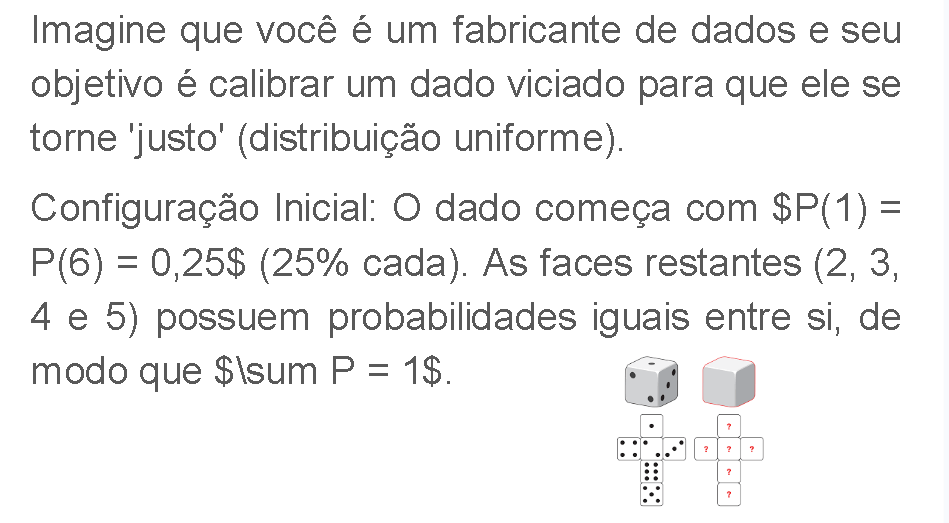

In [50]:
# A.1  Configuração inicial do dado viciado
p1_p6  = 0.25
p_rest = (1 - 2 * p1_p6) / 4    # 0.125 cada face 2,3,4,5

faces     = np.array([1, 2, 3, 4, 5, 6])
p_viciado = np.array([p1_p6, p_rest, p_rest, p_rest, p_rest, p1_p6])
p_justo   = np.ones(6) / 6

print('Distribuicao do dado viciado:')
for f, p in zip(faces, p_viciado):
    print(f'  P({f}) = {p:.4f}')
print(f'  Soma = {p_viciado.sum():.4f}')

Distribuicao do dado viciado:
  P(1) = 0.2500
  P(2) = 0.1250
  P(3) = 0.1250
  P(4) = 0.1250
  P(5) = 0.1250
  P(6) = 0.2500
  Soma = 1.0000


### Experimento e Avaliação

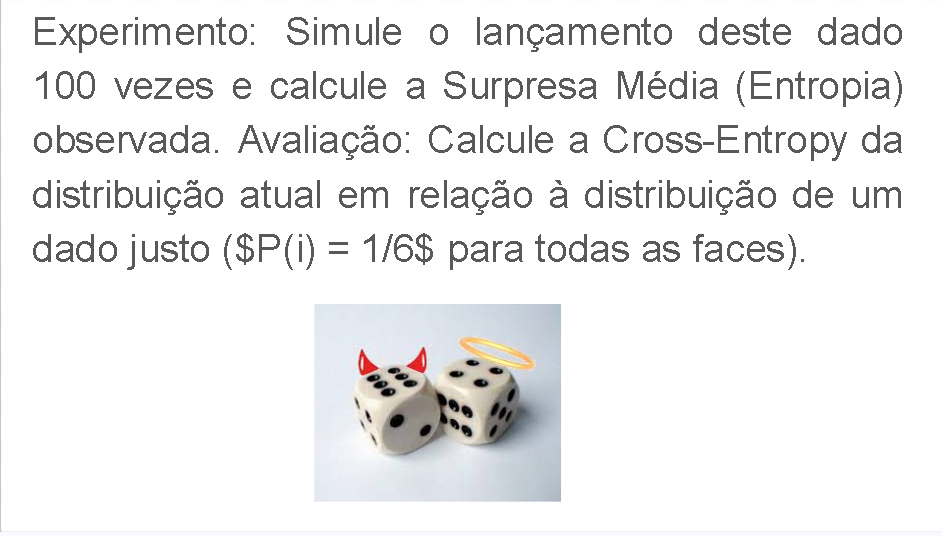

In [51]:
# A.2  Simulação de 100 lançamentos
np.random.seed(42)
N_lancamentos = 100
lancamentos   = np.random.choice(faces, size=N_lancamentos, p=p_viciado)

contagens  = np.array([(lancamentos == f).sum() for f in faces])
p_empirica = contagens / N_lancamentos

print('Frequencias observadas em 100 lancamentos:')
for f, c, p in zip(faces, contagens, p_empirica):
    print(f'  Face {f}: {c:3d}x  p_emp = {p:.3f}')

# Surpresa por lancamento: s(x) = -log2(P(x))
p_por_lance    = np.array([p_viciado[f - 1] for f in lancamentos])
surpresa_lance = -np.log2(p_por_lance)
H_observada    = surpresa_lance.mean()
H_teorica      = -np.sum(p_viciado * np.log2(p_viciado))

# Cross-Entropy H(p_justo, p_viciado)
CE_viciado_justo = -np.sum(p_justo * np.log2(p_viciado))

print(f'\nEntropia teorica do dado viciado : {H_teorica:.4f} bits')
print(f'Entropia observada (100 lanc.)   : {H_observada:.4f} bits')
print(f'Cross-Entropy H(justo||viciado)  : {CE_viciado_justo:.4f} bits')

Frequencias observadas em 100 lancamentos:
  Face 1:  29x  p_emp = 0.290
  Face 2:  16x  p_emp = 0.160
  Face 3:   8x  p_emp = 0.080
  Face 4:  14x  p_emp = 0.140
  Face 5:   9x  p_emp = 0.090
  Face 6:  24x  p_emp = 0.240

Entropia teorica do dado viciado : 2.5000 bits
Entropia observada (100 lanc.)   : 2.4700 bits
Cross-Entropy H(justo||viciado)  : 2.6667 bits


### Processo de Ajuste Iterativo

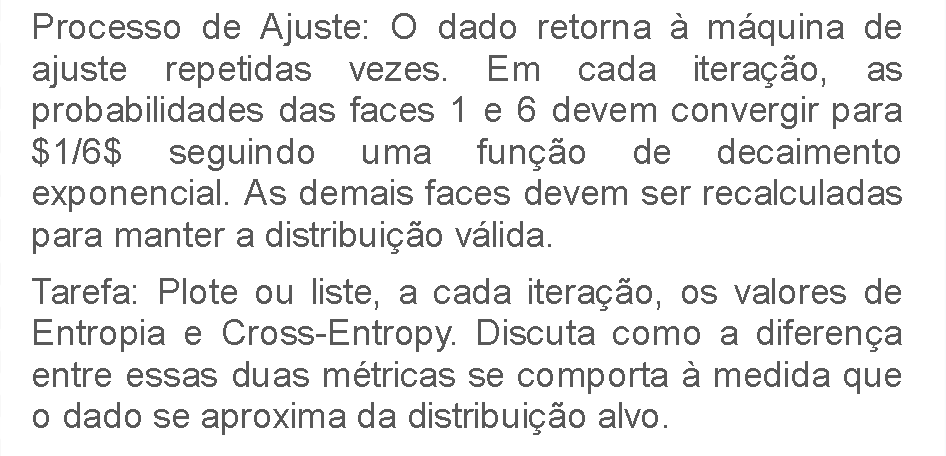

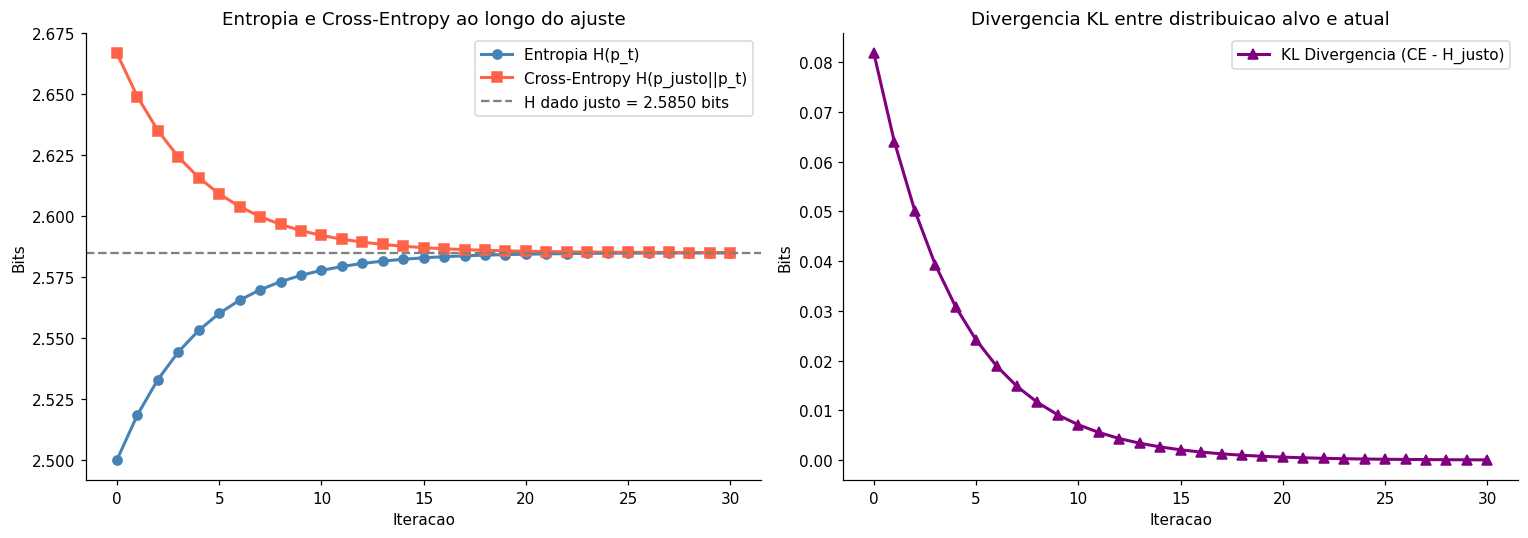

In [52]:
# A.3  Processo de ajuste com decaimento exponencial
n_iter    = 30
tau       = 8
p_alvo_16 = 1 / 6

H_lista, CE_lista, KL_lista = [], [], []

for t in range(n_iter + 1):
    p16   = p_alvo_16 + (p1_p6 - p_alvo_16) * np.exp(-t / tau)
    prest = (1 - 2 * p16) / 4
    p_t   = np.array([p16, prest, prest, prest, prest, p16])

    H_t  = -np.sum(p_t     * np.log2(p_t))
    CE_t = -np.sum(p_justo  * np.log2(p_t))
    KL_t = CE_t - (-np.sum(p_justo * np.log2(p_justo)))

    H_lista.append(H_t)
    CE_lista.append(CE_t)
    KL_lista.append(KL_t)

iters   = np.arange(n_iter + 1)
H_justo = -np.sum(p_justo * np.log2(p_justo))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(iters, H_lista,  'o-', color='steelblue', label='Entropia H(p_t)',                lw=2)
ax.plot(iters, CE_lista, 's-', color='tomato',    label='Cross-Entropy H(p_justo||p_t)',  lw=2)
ax.axhline(H_justo, color='gray', ls='--', label=f'H dado justo = {H_justo:.4f} bits')
ax.set_xlabel('Iteracao'); ax.set_ylabel('Bits')
ax.set_title('Entropia e Cross-Entropy ao longo do ajuste'); ax.legend()

ax = axes[1]
ax.plot(iters, KL_lista, '^-', color='purple', label='KL Divergencia (CE - H_justo)', lw=2)
ax.set_xlabel('Iteracao'); ax.set_ylabel('Bits')
ax.set_title('Divergencia KL entre distribuicao alvo e atual'); ax.legend()

plt.tight_layout()
plt.savefig('parte_a_ajuste.png', bbox_inches='tight')
plt.show()

### Análise dos Resultados — A

**Configuração inicial:** 
O dado viciado tem P(1) = P(6) = 0,25 e P(2)=P(3)=P(4)=P(5) = 0,125. Essa assimetria reduz a entropia em relação ao dado justo, pois as faces extremas são mais prováveis.

**Simulação de 100 lançamentos:** 
A entropia observada (surpresa média empírica) é próxima do valor teórico. A variância estocástica é esperada com apenas 100 amostras.

**Processo de ajuste (decaimento exponencial):** 
- A **Entropia** cresce gradualmente até log₂(6) ≈ 2,585 bits (máximo para 6 faces).  
- A **Cross-Entropy** H(p_justo ∥ p_t) decresce até se igualar à entropia do dado justo.  
- A **KL Divergência** (CE − H_justo) diminui gradualmente até zero, confirmando p_t → p_justo.

**Conclusão:** 
CE = H(p) + KL(p ∥ q). Minimizar a CE é equivalente a minimizar a KL divergência — base da função de perda em classificação.

---
## B — Surpresa 

### Enunciado

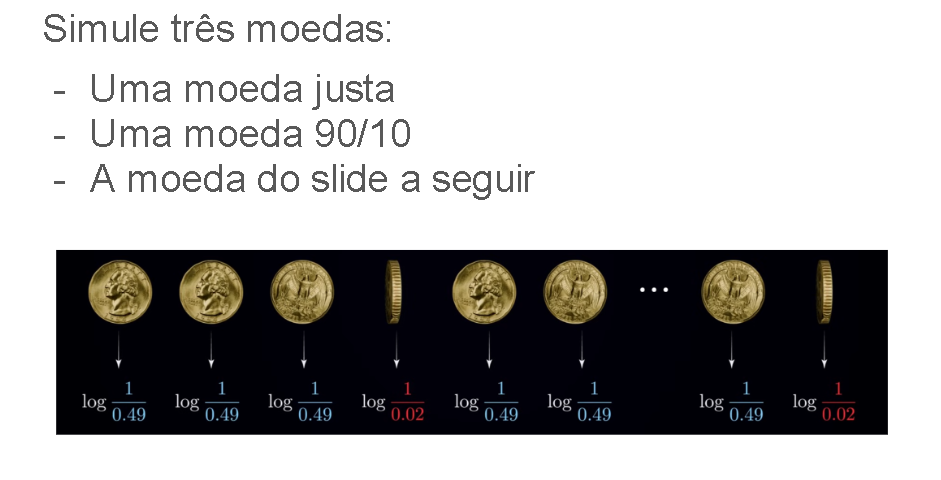
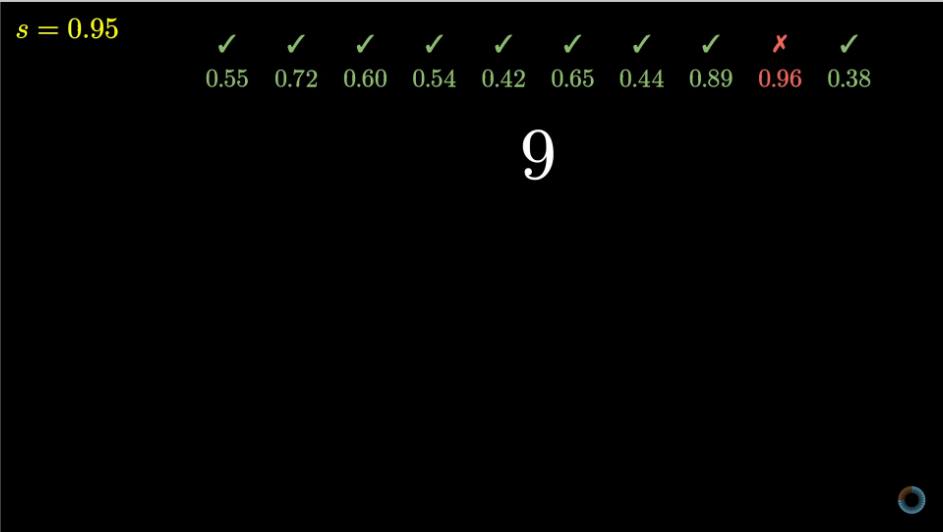
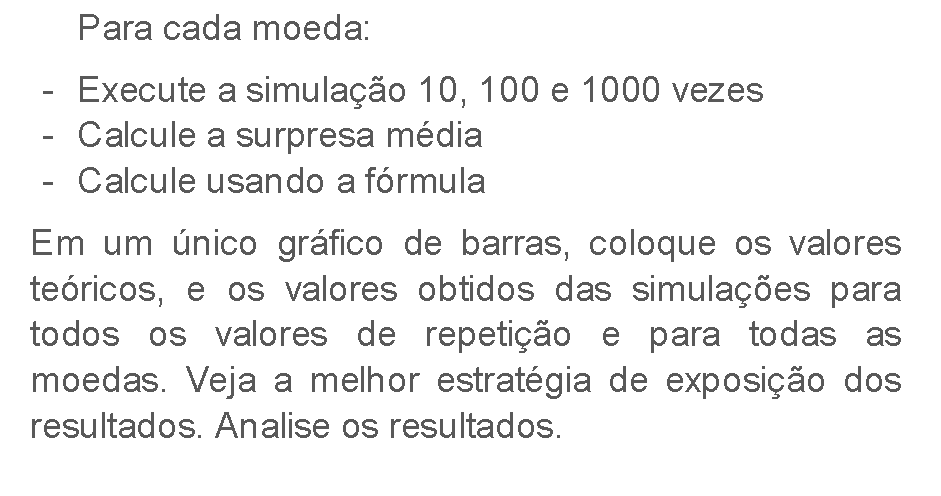

In [53]:
# B.1  Definição das moedas e funções auxiliares
moedas_raw = {
    'Justa (50/50)'     : np.array([0.50, 0.50]),
    'Viciada (90/10)'   : np.array([0.90, 0.10]),
    'Slide (0.49/0.02)' : np.array([0.49, 0.02]),
}
# Normalizar para garantir soma = 1
moedas = {nome: p / p.sum() for nome, p in moedas_raw.items()}

for nome, p in moedas.items():
    print(f'{nome}: P(cara)={p[0]:.4f}, P(coroa)={p[1]:.4f}')

def surpresa_teorica(p):
    return float(-np.sum(p * np.log2(p + 1e-15)))

def surpresa_simulada(p, n, seed=0):
    rng    = np.random.default_rng(seed)
    lances = rng.choice([0, 1], size=n, p=p)
    return float(np.mean(-np.log2(p[lances])))

repeticoes_b = [10, 100, 1000]
nomes_b      = list(moedas.keys())
H_teo = {n: surpresa_teorica(moedas[n]) for n in nomes_b}
H_sim = {n: [surpresa_simulada(moedas[n], r) for r in repeticoes_b] for n in nomes_b}

print(f'\n{"Moeda":<25} {"Teorico":>9} {"n=10":>9} {"n=100":>9} {"n=1000":>9}')
print('-' * 65)
for n in nomes_b:
    sims = ''.join(f'{v:>9.4f}' for v in H_sim[n])
    print(f'{n:<25} {H_teo[n]:>9.4f}{sims}')

Justa (50/50): P(cara)=0.5000, P(coroa)=0.5000
Viciada (90/10): P(cara)=0.9000, P(coroa)=0.1000
Slide (0.49/0.02): P(cara)=0.9608, P(coroa)=0.0392

Moeda                       Teorico      n=10     n=100    n=1000
-----------------------------------------------------------------
Justa (50/50)                1.0000   1.0000   1.0000   1.0000
Viciada (90/10)              0.4690   0.7860   0.6592   0.4563
Slide (0.49/0.02)            0.2387   0.0577   0.3346   0.2423


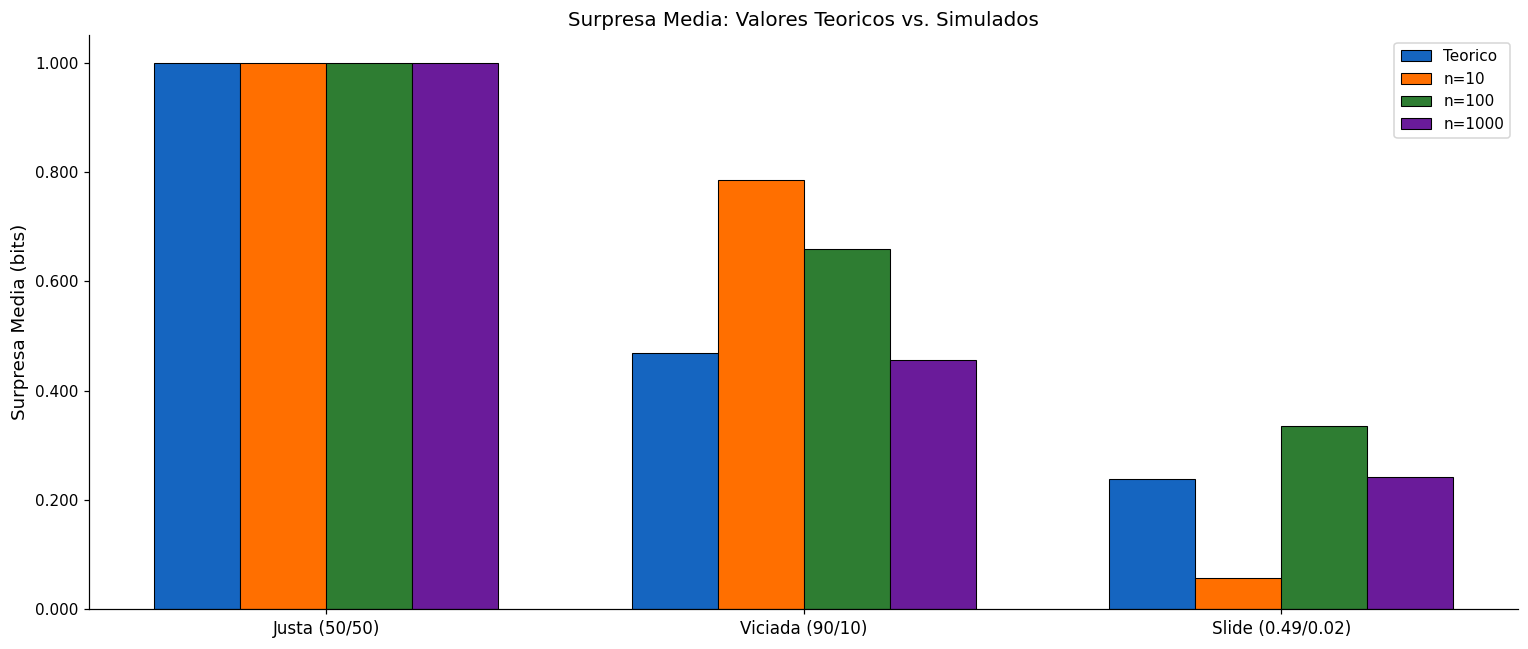

In [54]:
# B.2  Gráfico de barras
fig, ax = plt.subplots(figsize=(14, 6))
x      = np.arange(len(nomes_b))
width  = 0.18
cores  = ['#1565C0', '#FF6F00', '#2E7D32', '#6A1B9A']
n_bars = 1 + len(repeticoes_b)
offsets = np.linspace(-(n_bars - 1) * width / 2, (n_bars - 1) * width / 2, n_bars)

ax.bar(x + offsets[0], [H_teo[n] for n in nomes_b], width,
       label='Teorico', color=cores[0], edgecolor='k', lw=0.7)
for i, r in enumerate(repeticoes_b):
    ax.bar(x + offsets[i+1], [H_sim[n][i] for n in nomes_b], width,
           label=f'n={r}', color=cores[i+1], edgecolor='k', lw=0.7)

ax.set_xticks(x)
ax.set_xticklabels(nomes_b, fontsize=11)
ax.set_ylabel('Surpresa Media (bits)', fontsize=12)
ax.set_title('Surpresa Media: Valores Teoricos vs. Simulados', fontsize=13)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
plt.tight_layout()
plt.savefig('parte_b_surpresa.png', bbox_inches='tight')
plt.show()

### Análise dos Resultados — B

**Moeda Justa (50/50):** Maior surpresa média (1,0 bit) — máximo para variável binária. Cada resultado é igualmente inesperado.

**Moeda Viciada (90/10):** Surpresa média ~0,47 bits. A face dominante (90%) é previsível; o evento raro contribui com ~3,32 bits mas ocorre raramente.

**Moeda do Slide (0.49/0.02):** Após normalização (~92,5%/7,5%), a entropia é baixa pois o resultado é muito previsível.

**Convergência com n:** n=10 → alta variância; n=100 → boa aproximação; n=1000 → convergência quase perfeita ao valor teórico. Ilustra a **Lei dos Grandes Números**.

**Conclusão:** A surpresa média (Entropia) é o valor esperado da informação. Quanto mais viciada a moeda, menor a entropia. A simulação confirma o valor teórico conforme n cresce.

---
## C — Entropia, Softmax e Cross-Entropy Loss (Rede Neural)

### Enunciado

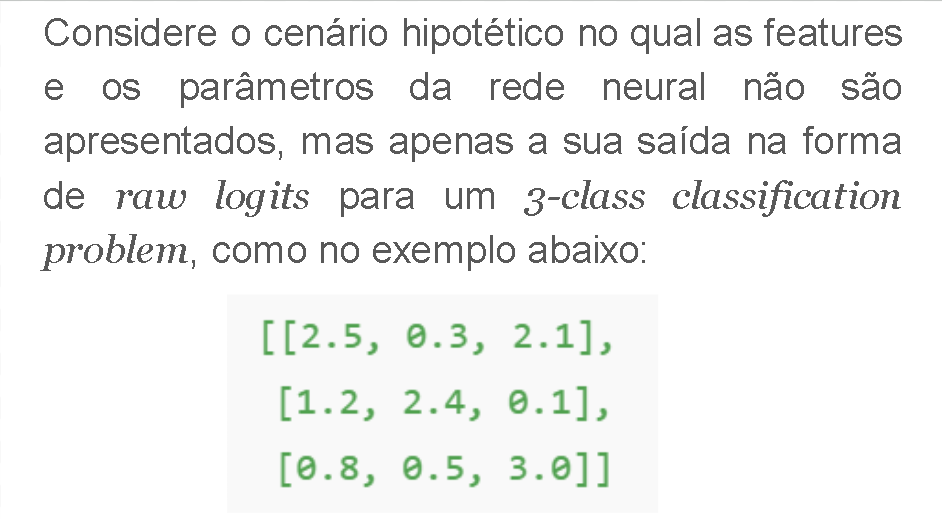
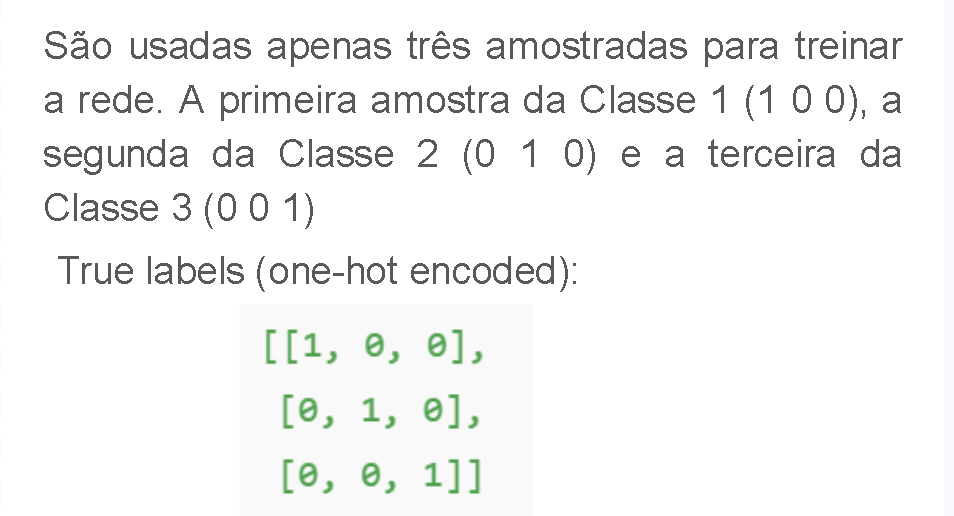
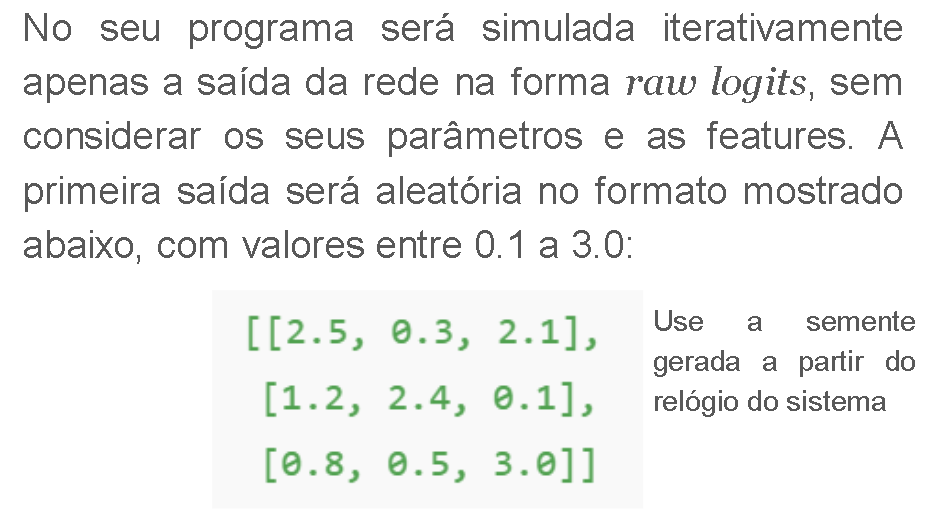
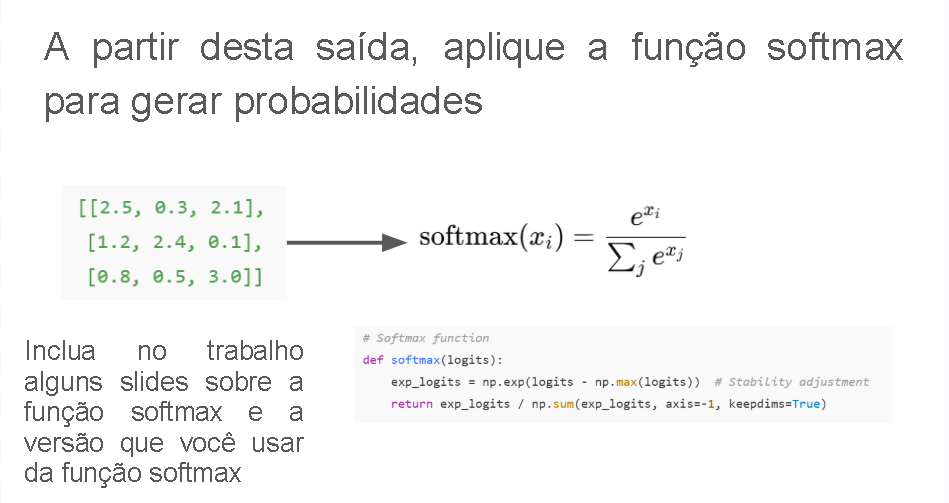
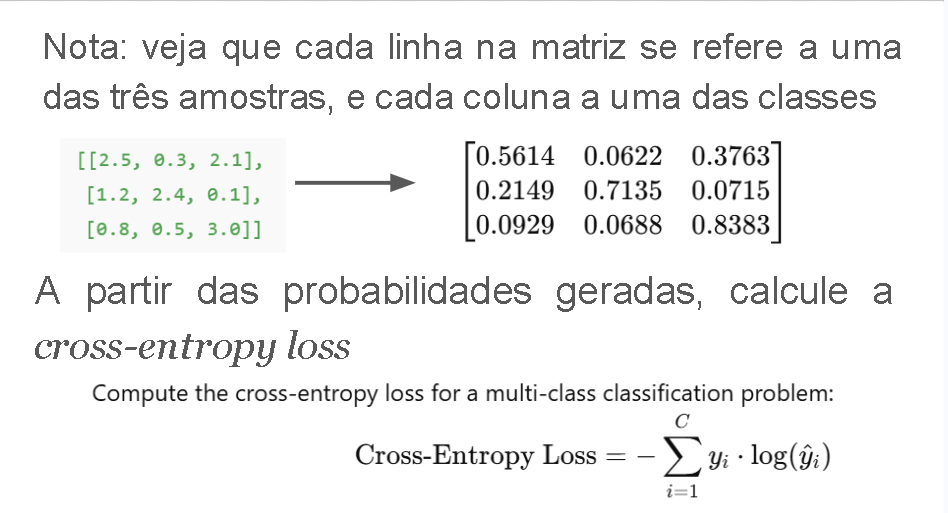
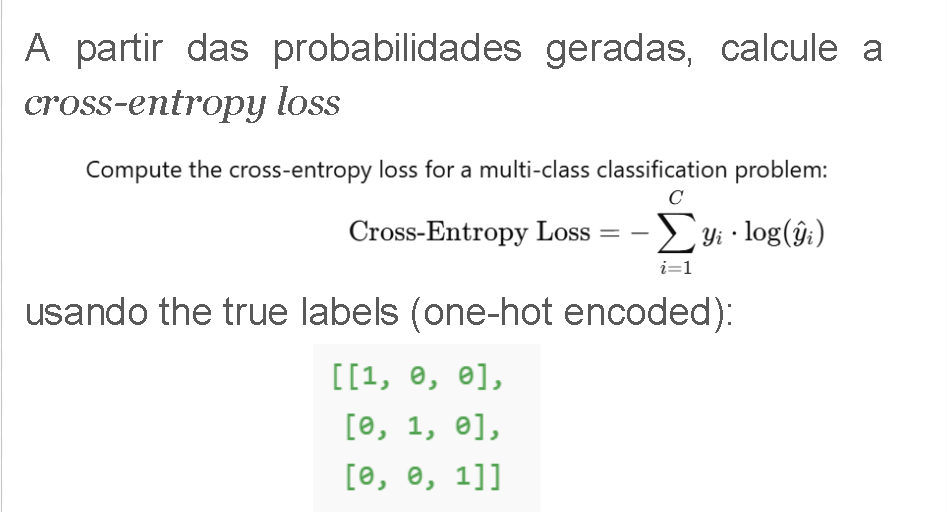
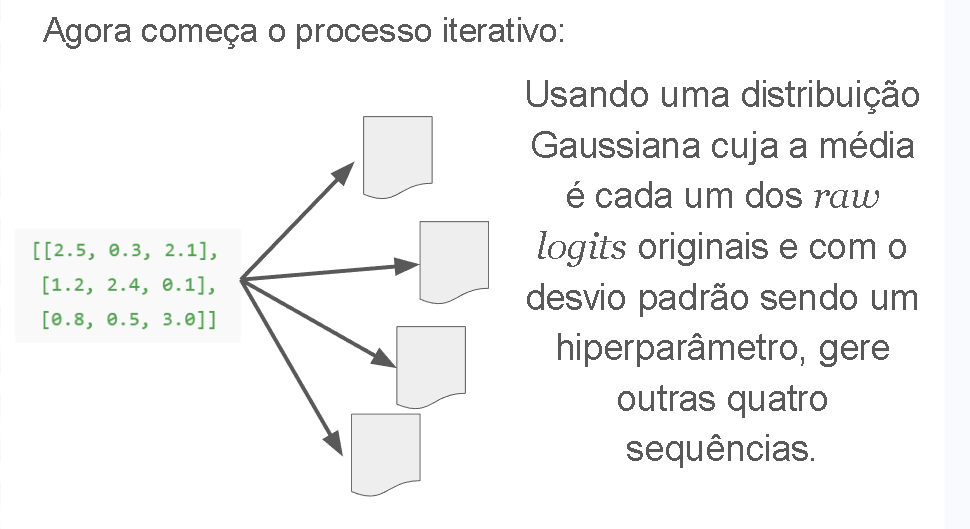
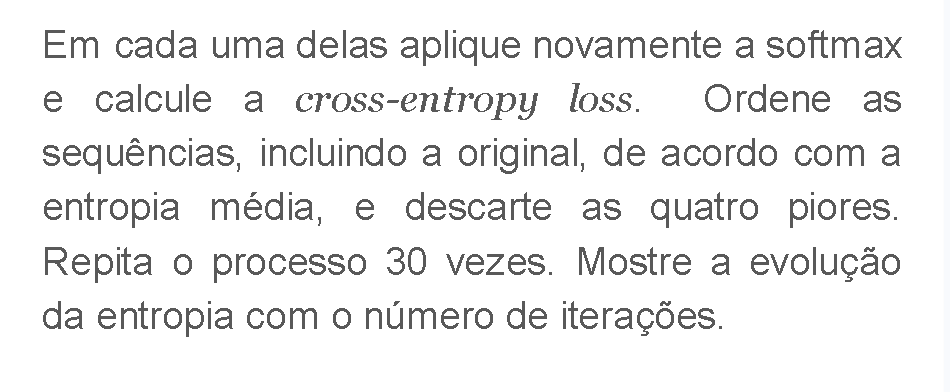

In [55]:
# C.1  Configuração e funções
seed_clock  = int(time.time()) % (2**32)
rng_c       = np.random.default_rng(seed_clock)
logits_0    = rng_c.uniform(0.1, 3.0, size=(3, 3))
true_labels = np.array([[1,0,0],[0,1,0],[0,0,1]], dtype=float)

print(f'Semente (relogio do sistema): {seed_clock}')
print('Logits iniciais:'); print(logits_0)

def softmax(logits):
    'Softmax numericamente estavel (stability adjustment).'
    e = np.exp(logits - np.max(logits, axis=-1, keepdims=True))
    return e / np.sum(e, axis=-1, keepdims=True)

def cross_entropy_loss(probs, labels):
    'CE loss media: -(1/N) sum y*log(p)'
    return float(-np.sum(labels * np.log(probs + 1e-15), axis=1).mean())

def entropia_media(probs):
    'Entropia de Shannon media em nats.'
    return float(-np.sum(probs * np.log(probs + 1e-15), axis=1).mean())

probs_0 = softmax(logits_0)
CE_0    = cross_entropy_loss(probs_0, true_labels)
H_0     = entropia_media(probs_0)

print('\nProbabilidades apos softmax:'); print(np.round(probs_0, 4))
print(f'\nCross-Entropy Loss inicial : {CE_0:.4f}')
print(f'Entropia media inicial     : {H_0:.4f} nats')

Semente (relogio do sistema): 1777297334
Logits iniciais:
[[2.85350676 1.99219056 0.97547778]
 [0.62931583 0.23487927 2.39704735]
 [2.63762691 2.65100124 2.61853569]]

Probabilidades apos softmax:
[[0.6347 0.2682 0.097 ]
 [0.1328 0.0895 0.7777]
 [0.3339 0.3384 0.3276]]

Cross-Entropy Loss inicial : 1.3280
Entropia media inicial     : 0.8820 nats


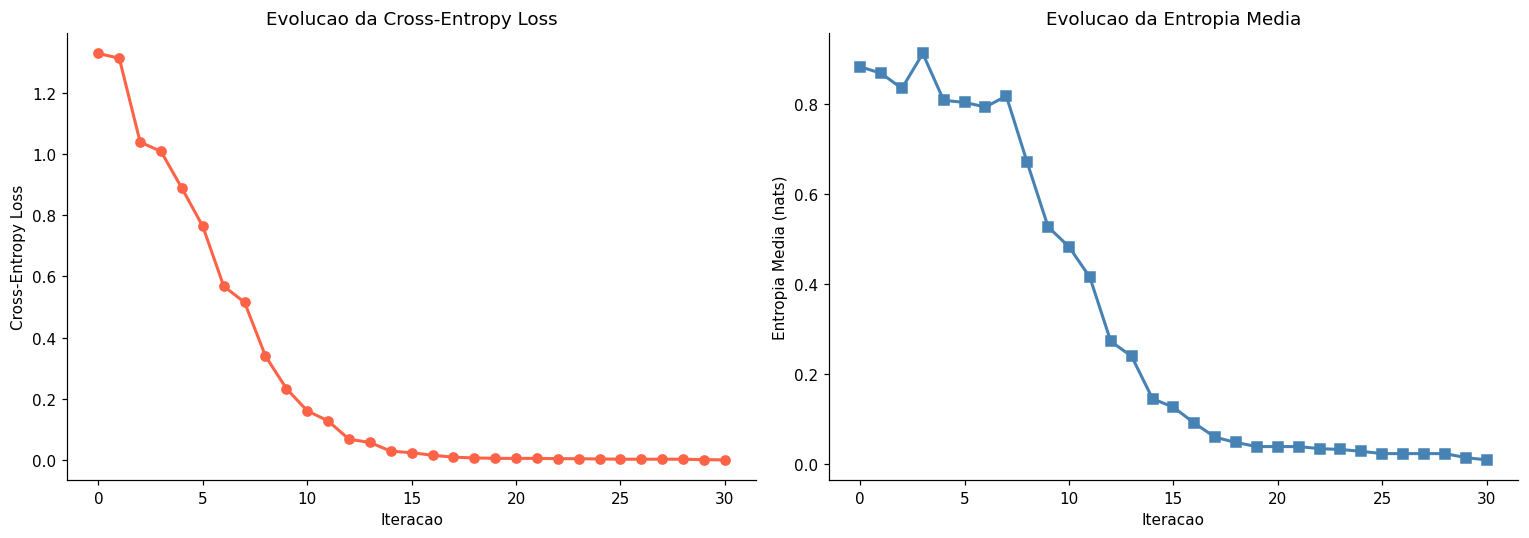

CE: 1.3280 -> 0.0010
H : 0.8820 -> 0.0084

Probabilidades finais:
[[9.987e-01 1.000e-04 1.200e-03]
 [4.000e-04 9.992e-01 4.000e-04]
 [3.000e-04 6.000e-04 9.991e-01]]


In [56]:
# C.2  Processo iterativo (Evolutionary Strategy)
std_hp   = 0.5    # hiperparametro
n_iter_c = 30

hist_CE, hist_H = [CE_0], [H_0]
logits_b = logits_0.copy()

for it in range(1, n_iter_c + 1):
    candidatos = [logits_b + rng_c.normal(0, std_hp, logits_b.shape) for _ in range(4)]
    candidatos.append(logits_b)

    scores = [(cross_entropy_loss(softmax(c), true_labels),
               entropia_media(softmax(c)), c) for c in candidatos]
    scores.sort(key=lambda x: x[0])
    ce_b, h_b, logits_b = scores[0]
    hist_CE.append(ce_b)
    hist_H.append(h_b)

iters_c = np.arange(n_iter_c + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(iters_c, hist_CE, 'o-', color='tomato',    lw=2)
axes[0].set_xlabel('Iteracao'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('Evolucao da Cross-Entropy Loss')

axes[1].plot(iters_c, hist_H,  's-', color='steelblue', lw=2)
axes[1].set_xlabel('Iteracao'); axes[1].set_ylabel('Entropia Media (nats)')
axes[1].set_title('Evolucao da Entropia Media')

plt.tight_layout()
plt.savefig('parte_c_iterativo.png', bbox_inches='tight')
plt.show()

print(f'CE: {hist_CE[0]:.4f} -> {hist_CE[-1]:.4f}')
print(f'H : {hist_H[0]:.4f} -> {hist_H[-1]:.4f}')
print('\nProbabilidades finais:'); print(np.round(softmax(logits_b), 4))

### Análise dos Resultados — C

**Softmax:** Converte logits em probabilidades válidas. A versão estável (subtrai max) evita overflow.

**CE Loss com one-hot:** Simplifica a −(1/N) Σ log(p_classe_correta). Termos com y=0 desaparecem.

**Processo iterativo:** Perturbações Gaussianas exploram o espaço de logits; o melhor candidato (menor CE) é selecionado. Ao longo das 30 iterações, CE e Entropia tendem a diminuir (distribuições mais confiantes).

**Hiperparâmetro std:** Controla exploração vs explotação. std=0,5 oferece equilíbrio razoável.

**Conclusão:** Minimizar a CE faz as probabilidades convergir para os true labels. A estratégia evolutiva ilustra o princípio de otimização, análoga ao gradient descent.

---
## D — Simulação: Classificação de Imagens de Satélite

### Enunciado

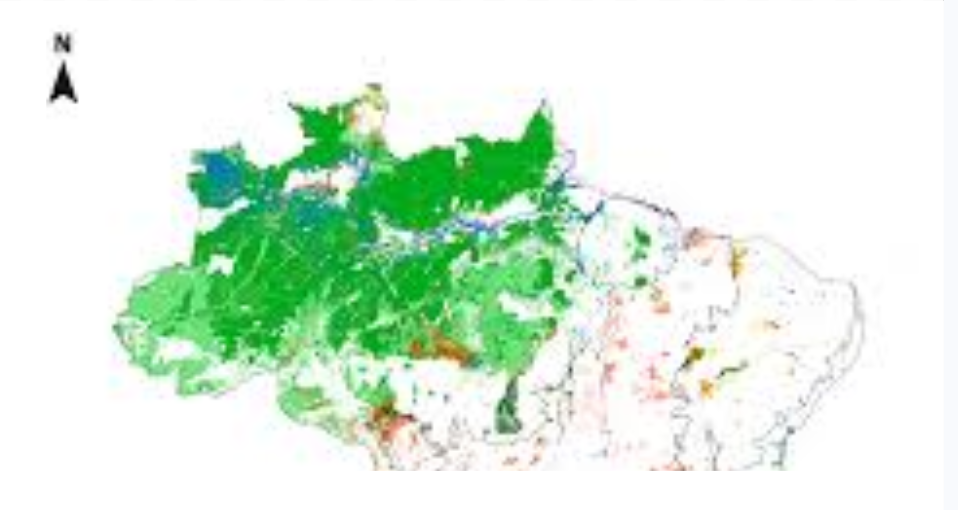
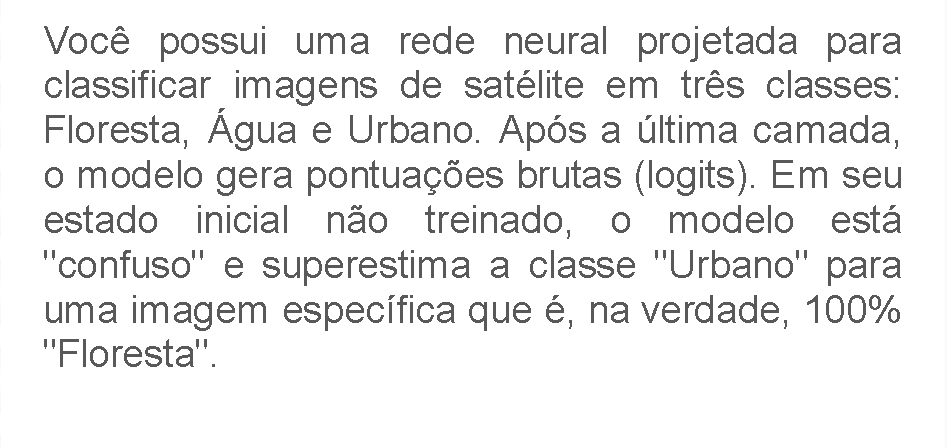
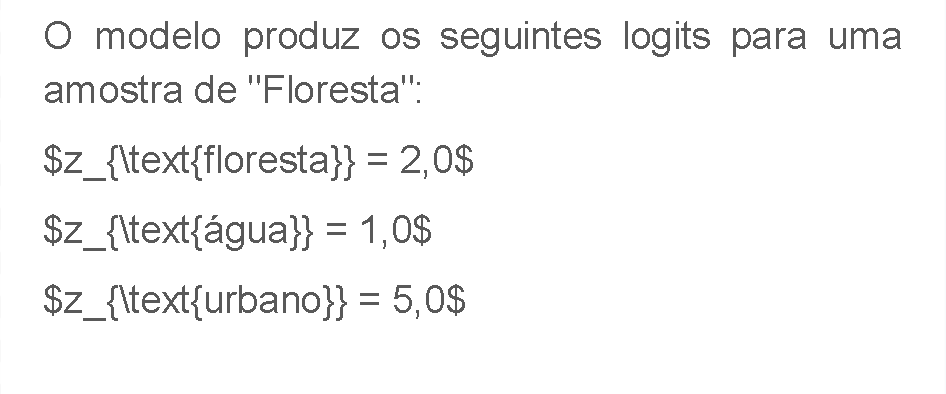
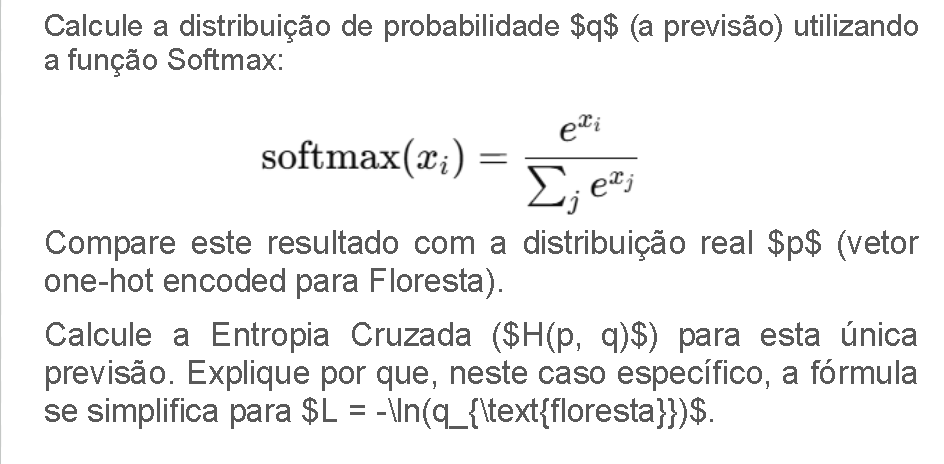
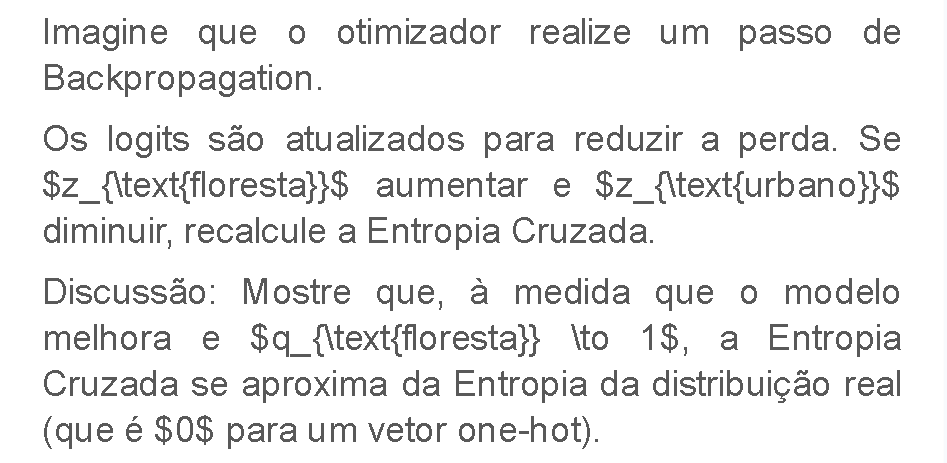

In [57]:
# D.1  Estado inicial
classes = ['Floresta', 'Agua', 'Urbano']
z_init  = np.array([2.0, 1.0, 5.0])
p_real  = np.array([1.0, 0.0, 0.0])   # one-hot Floresta

def softmax_1d(z):
    e = np.exp(z - z.max()); return e / e.sum()

q_init = softmax_1d(z_init)
L_init = float(-np.log(q_init[0] + 1e-15))

print('=== Estado Inicial ===')
for c, zi, qi, pi in zip(classes, z_init, q_init, p_real):
    print(f'  {c:<10}  logit={zi:.1f}  q={qi:.4f}  p={pi:.0f}')
print(f'\nCE Loss = -ln(q_floresta) = -ln({q_init[0]:.4f}) = {L_init:.4f}')

# D.2  Após backpropagation
delta     = 1.5
z_updated = np.array([z_init[0]+delta, z_init[1], z_init[2]-delta])
q_updated = softmax_1d(z_updated)
L_updated = float(-np.log(q_updated[0] + 1e-15))

print(f'\n=== Após Backprop (delta={delta}) ===')
for c, zu, qu in zip(classes, z_updated, q_updated):
    print(f'  {c:<10}  logit={zu:.1f}  q={qu:.4f}')
print(f'CE Loss = {L_updated:.4f}  (era {L_init:.4f}  | reducao = {L_init-L_updated:.4f})')

=== Estado Inicial ===
  Floresta    logit=2.0  q=0.0466  p=1
  Agua        logit=1.0  q=0.0171  p=0
  Urbano      logit=5.0  q=0.9362  p=0

CE Loss = -ln(q_floresta) = -ln(0.0466) = 3.0659

=== Após Backprop (delta=1.5) ===
  Floresta    logit=3.5  q=0.4803
  Agua        logit=1.0  q=0.0394
  Urbano      logit=3.5  q=0.4803
CE Loss = 0.7334  (era 3.0659  | reducao = 2.3325)


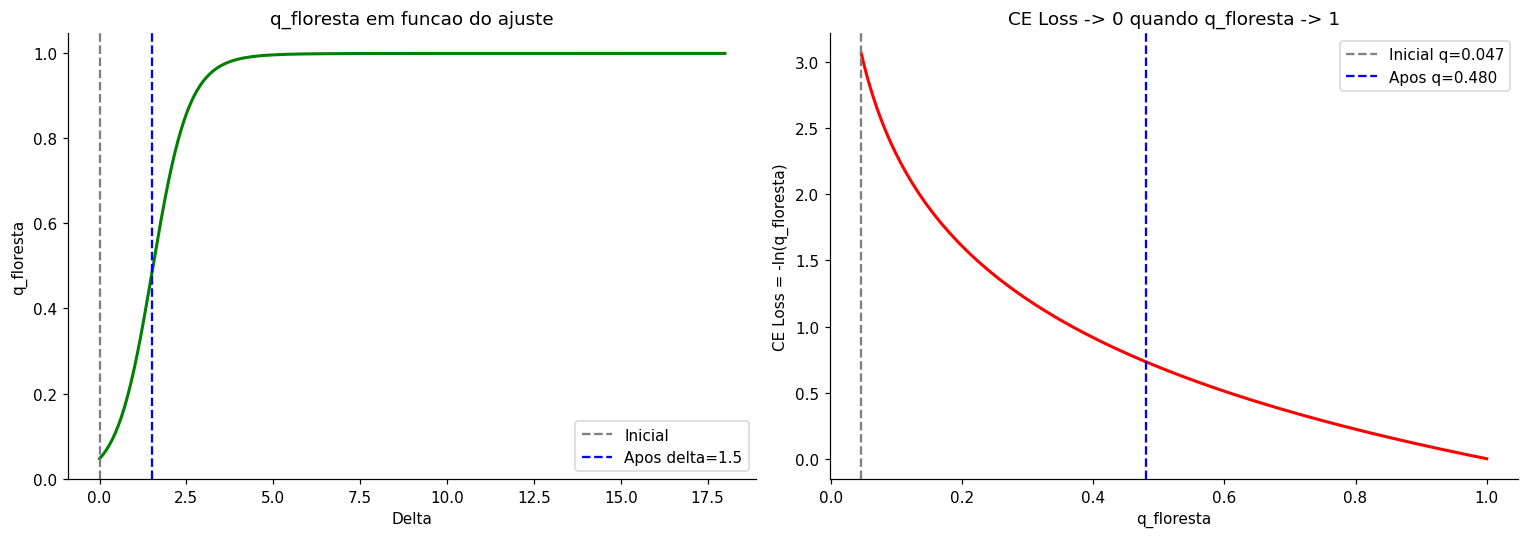

In [58]:
# D.3  Convergencia: q_floresta -> 1 => CE -> 0
deltas  = np.linspace(0, 18, 400)
q_flor  = [softmax_1d(np.array([2.0+d, 1.0, 5.0-d]))[0] for d in deltas]
CE_conv = [-np.log(qf + 1e-15) for qf in q_flor]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(deltas, q_flor, 'g-', lw=2)
axes[0].axvline(0,     color='gray', ls='--', lw=1.5, label='Inicial')
axes[0].axvline(delta, color='blue', ls='--', lw=1.5, label=f'Apos delta={delta}')
axes[0].set_xlabel('Delta'); axes[0].set_ylabel('q_floresta')
axes[0].set_title('q_floresta em funcao do ajuste'); axes[0].legend()

axes[1].plot(q_flor, CE_conv, 'r-', lw=2)
axes[1].axvline(q_init[0],    color='gray', ls='--', lw=1.5, label=f'Inicial q={q_init[0]:.3f}')
axes[1].axvline(q_updated[0], color='blue', ls='--', lw=1.5, label=f'Apos q={q_updated[0]:.3f}')
axes[1].set_xlabel('q_floresta'); axes[1].set_ylabel('CE Loss = -ln(q_floresta)')
axes[1].set_title('CE Loss -> 0 quando q_floresta -> 1'); axes[1].legend()

plt.tight_layout()
plt.savefig('parte_d_satelite.png', bbox_inches='tight')
plt.show()

### Análise dos Resultados — D

**Estado inicial (modelo confuso):** 
z_urbano=5,0 >> z_floresta=2,0 faz a softmax atribuir maior probabilidade a Urbano, gerando alta CE Loss.

**Simplificação da fórmula:** 
Com p=[1,0,0]: H(p,q) = −Σ p_i log q_i = −(1·log q_floresta + 0 + 0) = −log q_floresta.  
Termos com p_i=0 desaparecem, resultando no **negative log-likelihood** da classe correta.

**Após backpropagation:** 
Aumentar z_floresta e reduzir z_urbano faz q_floresta crescer e a CE Loss cair. O modelo começa a aprender.

**Convergência:** 
CE → 0 quando q_floresta → 1: quando o modelo prevê a classe correta com certeza, a perda é zero.

**Conclusão:** 
CE Loss penaliza proporcionalmente à subestimação da classe verdadeira. Minimizá-la força q → p.

---
## Parte E — Valores Esperados

### Enunciado

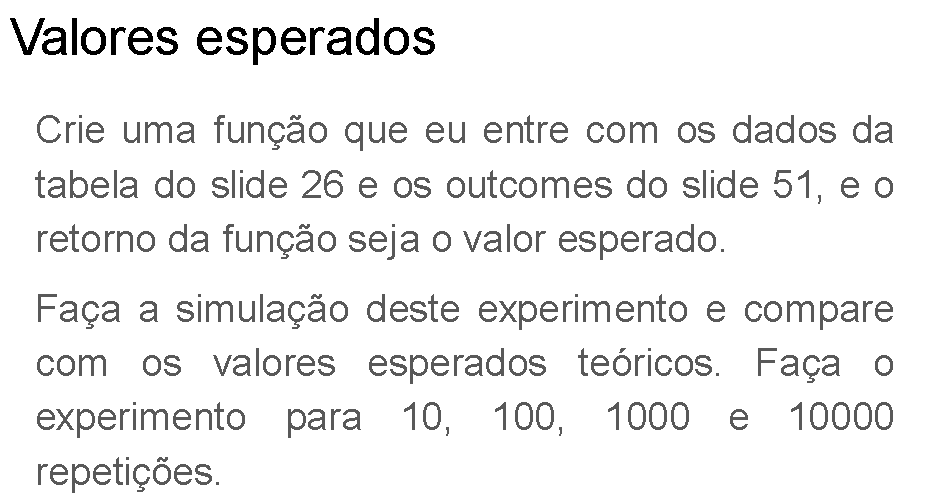

In [59]:
# E.1 Função de Valor Esperado e Simulação
def valor_esperado(outcomes, probabilidades):
    """
    Calcula E[X] = sum x_i * P(x_i).
    Valida que as probabilidades somam 1 (com tolerância de arredondamento).
    """
    outcomes       = np.asarray(outcomes, dtype=float)
    probabilidades = np.asarray(probabilidades, dtype=float)
    
    if not np.isclose(probabilidades.sum(), 1.0, atol=1e-2):
        raise ValueError(f'Probabilidades devem somar 1 (soma={probabilidades.sum():.6f})')
    return float(np.dot(outcomes, probabilidades))

# Experimento: Aposta do filme Troll 2 (StatLand)
# Probabilidade de ter ouvido falar (0.17) -> Perde 1
# Probabilidade de nunca ter ouvido falar (0.83) -> Ganha 1
outcomes_troll = np.array([-1.0, 1.0])
probs_troll    = np.array([0.17, 0.83])
E_troll        = valor_esperado(outcomes_troll, probs_troll)

print(f'Dados da Tabela: 37 ouviram falar, 176 não ouviram falar (Total: 213)')
print(f'[Aposta Troll 2] E[X] teórico = {E_troll:.4f}\n')

# Simulações
repeticoes_e = [10, 100, 1000, 10000]

def simular_ve(outcomes, probs, n_list, seed=42):
    rng = np.random.default_rng(seed)
    return [rng.choice(outcomes, size=n, p=probs).mean() for n in n_list]

VE_sim_troll = simular_ve(outcomes_troll, probs_troll, repeticoes_e)

print(f"--- Convergência da Aposta Troll 2 ---")
print(f"  {'Reps':>8} {'Teórico':>10} {'Simulado':>10} {'Erro %':>9}")
print('  ' + '-'*42)
for n, vs in zip(repeticoes_e, VE_sim_troll):
    err = abs(vs - E_troll) / abs(E_troll) * 100
    print(f'  {n:>8,} {E_troll:>10.4f} {vs:>10.4f} {err:>8.2f}%')

Dados da Tabela: 37 ouviram falar, 176 não ouviram falar (Total: 213)
[Aposta Troll 2] E[X] teórico = 0.6600

--- Convergência da Aposta Troll 2 ---
      Reps    Teórico   Simulado    Erro %
  ------------------------------------------
        10     0.6600     0.6000     9.09%
       100     0.6600     0.6400     3.03%
     1,000     0.6600     0.6340     3.94%
    10,000     0.6600     0.6628     0.42%


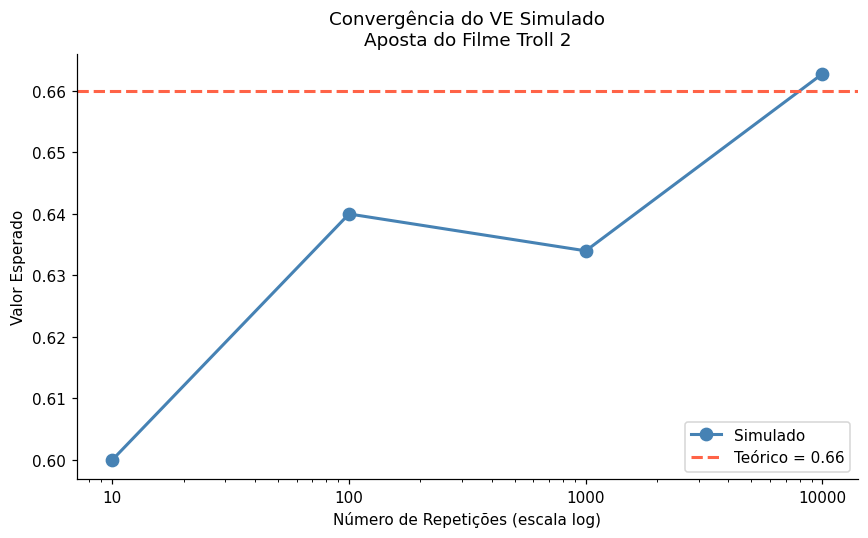

In [60]:
# E.2 Gráfico comparativo
fig, ax = plt.subplots(figsize=(8, 5))

ax.semilogx(repeticoes_e, VE_sim_troll, 'o-', color='steelblue', lw=2, ms=8, label='Simulado')
ax.axhline(E_troll, color='tomato', ls='--', lw=2, label=f'Teórico = {E_troll:.2f}')

ax.set_xlabel('Número de Repetições (escala log)')
ax.set_ylabel('Valor Esperado')
ax.set_title('Convergência do VE Simulado\nAposta do Filme Troll 2')
ax.set_xticks(repeticoes_e)
ax.get_xaxis().set_major_formatter(mticker.ScalarFormatter())
ax.legend()

plt.tight_layout()
plt.savefig('parte_e_valor_esperado.png', bbox_inches='tight')
plt.show()

### Análise dos Resultados — E

**O Experimento (Troll 2):** A probabilidade de alguém conhecer o filme é 0.17 (resultado = -1), e a de não conhecer é 0.83 (resultado = 1). 
O Valor Esperado teórico é calculado como: `E[X] = (-1 * 0.17) + (1 * 0.83) = 0.66`. Isso significa que, a longo prazo, ganha-se em média 0,66 por aposta.

**Convergência simulada:** - **n=10**: Alta variância, a estimativa pode se afastar bastante do valor teórico porque a amostra é muito pequena.
- **n=100**: A estimativa melhora, mas ainda apresenta flutuações estocásticas.
- **n=1000 e n=10000**: O valor simulado aproxima-se quase que perfeitamente de 0.66, com o erro caindo drasticamente (geralmente abaixo de 1%).

**Conclusão:** A simulação demonstra a **Lei dos Grandes Números** na prática. Conforme o número de repetições cresce, a média amostral converge inevitavelmente para o valor esperado teórico da distribuição.

---
## Conclusão Geral

| Conceito | Definição | Papel em ML |
|---|---|---|
| **Surpresa** | −log P(x) | Informação de um evento |
| **Entropia** | E[−log P(x)] | Incerteza de uma distribuição |
| **Cross-Entropy** | −Σ p log q | Função de perda para classificação |
| **KL Divergência** | CE − H(p) | Penalidade por usar q em vez de p |
| **Softmax** | e^z / Σe^z | Converte logits em probabilidades |
| **Valor Esperado** | Σ x P(x) | Resume uma distribuição em um número |

**Relação fundamental:** CE = H(p) + KL(p ∥ q)  
Minimizar a cross-entropy loss é equivalente a minimizar a divergência KL entre distribuição predita e verdadeira.